# ML Models 01 - Feature Engineering

**Goal:** Build lag features and the target variable.
The output is a DataFrame ready for LightGBM training.

**Before you start:** Make sure `data/gold/cards.duckdb` exists and contains `gold_price_features`.

**Run all cells top to bottom. Fill in the Observations section at the end.**

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parents[1]))

In [2]:
import duckdb
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, "..")

DB_PATH = "../../data/gold/cards.duckdb"
conn = duckdb.connect(DB_PATH, read_only=True)
print("Connected to DuckDB")

Connected to DuckDB


## 1. Building Lag Features

**What is a lag feature?**
Given prices `[1.0, 1.1, 1.2, 1.3]`, `lag_1d = [NaN, 1.0, 1.1, 1.2]` — "what was the price yesterday."

**Important — DATA GATE:**
`LAG(eur, N)` is row-based, not date-based. A card needs ≥ N+1 rows in `gold_price_features`
to produce a non-null `lag_N`:
- `lag_1d` ✓ needs 2 rows per card
- `lag_7d` ✓ needs 8 rows per card (gold has 8 snapshots as of 2026-06-11)
- `lag_14d`, `lag_30d` ✗ for 15 and 31 rows respectively

`build_target` also needs `snapshot_date + 7` to exist. The cell below finds a usable date automatically.

> **Note:** `lag_7d` is available at `SNAPSHOT_DATE = 2026-06-11` (8th snapshot), but that date
> has no target yet (needs 2026-06-18). The first date where **both** lag_7d and target exist
> will be ~2026-06-18. Until then, lag features improve gradually as snapshots accumulate.

In [3]:
from src.ml.features.lag import build_lag_features, build_target

# Find the latest snapshot_date for which snapshot_date + 7 days also exists.
# Falls back to the latest available date when no such pair exists yet
# (training will be empty, but lag features can still be inspected).
row = conn.execute("""
    SELECT MAX(t0.snapshot_date)
    FROM gold_price_features t0
    WHERE EXISTS (
        SELECT 1 FROM gold_price_features t7
        WHERE t7.snapshot_date = CAST(t0.snapshot_date AS DATE) + INTERVAL 7 DAY
    )
""").fetchone()[0]

if row:
    SNAPSHOT_DATE = str(row)
    print(f"Usable snapshot_date (target exists): {SNAPSHOT_DATE}")
else:
    SNAPSHOT_DATE = conn.execute(
        "SELECT MAX(snapshot_date) FROM gold_price_features"
    ).fetchone()[0]
    SNAPSHOT_DATE = str(SNAPSHOT_DATE)
    print(
        f"DATA GATE: no t+7 snapshot yet. Inspecting latest available: {SNAPSHOT_DATE}"
    )
    print(
        "Training (X, y) will be empty — come back when 14+ daily snapshots are collected."
    )

lag_df = build_lag_features(conn, SNAPSHOT_DATE)
target_df = build_target(conn, SNAPSHOT_DATE)

print(f"\nLag features: {lag_df.shape}")
print(f"Target:       {target_df.shape}")
lag_df.head()

Usable snapshot_date (target exists): 2026-07-02



Lag features: (96261, 14)
Target:       (93386, 2)


,uuid,snapshot_date,eur,edhrec_rank,foil_premium,lag_1d,lag_7d,lag_14d,lag_30d,rolling_mean_7d,rolling_std_14d,rolling_min_30d,rolling_max_30d,momentum_7d
0,6d023c7b-81df-5bf8-afc5-45d8448b1f48,2026-07-02,3.36,3594.0,1.636905,3.36,3.36,3.36,NaN,3.36,0.0,3.36,3.36,0.0
1,6d0f139b-b10f-57b0-bc01-2c06c4d3cf60,2026-07-02,3.79,515.0,NaN,3.79,3.79,3.79,3.79,3.79,0.0,3.79,3.79,0.0
2,6d144312-40c2-5f4d-9083-a39190fc28df,2026-07-02,0.03,17469.0,5.333333,0.03,0.03,0.03,0.03,0.03,0.0,0.03,0.03,0.0
3,6d3759e0-5436-576e-a4ca-5cca8a2a42df,2026-07-02,0.24,NaN,NaN,0.24,0.24,0.24,0.24,0.24,0.0,0.24,0.24,0.0
4,6d6a9e78-4edd-5c74-97d6-1f9130edac14,2026-07-02,NaN,26272.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing Value Analysis

**Why are there NaNs?**
`LAG(eur, N)` is row-based: at `SNAPSHOT_DATE = 2026-06-04` (the first row in `gold_price_features`),
every lag column is NaN because there are no prior rows to look back at.

Rolling features use `ROWS BETWEEN N PRECEDING AND CURRENT ROW` — they compute on whatever
rows are available. At the first snapshot, `rolling_mean_7d` / `rolling_min/max_30d` return
the current price (window of 1). `rolling_std_14d` needs ≥ 2 rows so it is NaN at the first snapshot.

`eur = NaN` (16.2% of cards) means the card has no Scryfall EUR price on this snapshot date.
This propagates to all price-derived columns — it is not a pipeline bug.

In [4]:
# NaN rate per column
null_pct = lag_df.isnull().mean().sort_values(ascending=False)
print("NaN rate per column:")
print(null_pct.to_string())

# Cards with complete lag_7d (required for the base model)
complete_7d = lag_df["lag_7d"].notna().sum()
print(
    f"\nCards with complete lag_7d: {complete_7d}/{len(lag_df)} ({100 * complete_7d / len(lag_df):.1f}%)"
)
complete_30d = lag_df["lag_30d"].notna().sum()
print(
    f"Cards with complete lag_30d: {complete_30d}/{len(lag_df)} ({100 * complete_30d / len(lag_df):.1f}%)"
)

NaN rate per column:
foil_premium       0.520356
lag_30d            0.169882
lag_1d             0.161062
lag_14d            0.161062
lag_7d             0.161062
eur                0.161062
rolling_std_14d    0.161062
rolling_min_30d    0.161062
rolling_max_30d    0.161062
rolling_mean_7d    0.161062
momentum_7d        0.161062
edhrec_rank        0.048846
uuid               0.000000
snapshot_date      0.000000

Cards with complete lag_7d: 80757/96261 (83.9%)
Cards with complete lag_30d: 79908/96261 (83.0%)


## 3. Feature Pipeline

The **pipeline** joins lag features with static card attributes (rarity, edhrec_rank, etc.)
and transforms them into the format expected by LightGBM.

Import from `src/ml/features/pipeline.py`.
`prepare_training_data` performs inner joins on `uuid` — cards missing lag history,
card metadata, or a target value are silently excluded.

In [5]:
from src.ml.features.pipeline import build_feature_pipeline, prepare_training_data

# Static card attributes (rarity, foil, edhrec_rank, legality flags, etc.)
card_df = conn.execute("SELECT * FROM gold_card_features").df()

pipeline = build_feature_pipeline()
X, y = prepare_training_data(lag_df, card_df, target_df)

print(f"Feature matrix: {X.shape}")
print(f"Target:         {y.shape}")
print("Sample features:", X.columns.tolist()[:10])

if X.empty:
    print(
        "\nDATA GATE: X is empty. target_df has 0 rows because snapshot_date + 7 is not yet"
    )
    print("in the database. Re-run after 14+ daily snapshots are collected.")

Feature matrix: (93386, 39)
Target:         (93386,)
Sample features: ['uuid', 'snapshot_date', 'eur', 'edhrec_rank', 'foil_premium', 'lag_1d', 'lag_7d', 'lag_14d', 'lag_30d', 'rolling_mean_7d']


## 4. Target Variable Distribution

**What we visualise:** distribution of `log_return_7d` — the predicted 7-day price change.
It should be roughly symmetric around 0 (rises and falls equally frequent).
A strong skew toward positive values would suggest most cards appreciate — note it in Observations.

`momentum_7d` is also plotted as a sanity check that the directional feature aligns with the target.

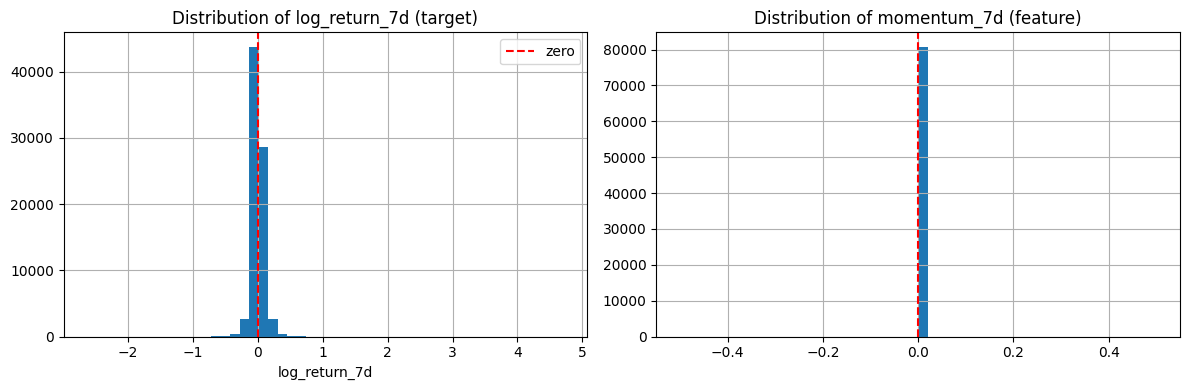

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not y.empty:
    y.hist(bins=50, ax=axes[0])
    axes[0].set_title("Distribution of log_return_7d (target)")
    axes[0].set_xlabel("log_return_7d")
    axes[0].axvline(0, color="red", linestyle="--", label="zero")
    axes[0].legend()
else:
    axes[0].text(
        0.5,
        0.5,
        "No target data yet\n(DATA GATE: need 14+ snapshots)",
        ha="center",
        va="center",
        transform=axes[0].transAxes,
    )
    axes[0].set_title("Distribution of log_return_7d (target)")

if "momentum_7d" in lag_df.columns and lag_df["momentum_7d"].notna().any():
    lag_df["momentum_7d"].hist(bins=50, ax=axes[1])
    axes[1].set_title("Distribution of momentum_7d (feature)")
    axes[1].axvline(0, color="red", linestyle="--")
else:
    axes[1].text(
        0.5,
        0.5,
        "momentum_7d all NaN\n(needs 8+ snapshots per card)",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
    )
    axes[1].set_title("Distribution of momentum_7d (feature)")

plt.tight_layout()
plt.show()

In [7]:
conn.close()

## Observations

*(Results from a fresh run: `SNAPSHOT_DATE = 2026-07-02` — the latest date in `gold_price_features` for which a t+7 target date also exists. `gold_price_features` now spans well beyond the 8-snapshot window of the previous run.)*

- **Cards with complete lag_7d:** 80,757 / 96,261 (83.9%)
  Up from 0/98,353 (0.0%) in the previous run. The 16.1% still missing are cards with `eur = NaN`
  on this snapshot date (no Scryfall EUR price), which propagates to every price-derived lag/rolling column
  (`lag_1d`, `lag_7d`, `lag_14d`, `rolling_mean_7d`, `rolling_std_14d`, `rolling_min_30d`, `rolling_max_30d`,
  `momentum_7d` all share the same 16.1062% NaN rate).

- **Cards with complete lag_30d:** 79,908 / 96,261 (83.0%)
  `lag_30d` has a slightly higher NaN rate (16.99%) than the other lag columns — a small extra slice of cards
  lack the 31 rows required, on top of the cards missing `eur` outright.

- **rolling_std_14d:** shares the 16.1% NaN rate with the other price-derived columns (not a distinct data gate
  anymore). This notebook does not plot its distribution, so whether it cleanly separates stable from
  speculative cards isn't directly assessable here — the sample rows printed above all show
  `rolling_std_14d = 0.0`, consistent with T6's finding that most (Tier-1) prices are flat over the
  relevant window.

- **momentum_7d distribution:** now populated (no longer all-NaN), but overwhelmingly concentrated at 0 —
  the histogram is effectively a single spike near zero on a [-0.5, 0.5] axis range, with no visible spread
  at that scale. Not meaningfully assessable for symmetry; this matches T6's observation that ~84% of cards
  have byte-identical prices after 7 days.

- **log_return_7d distribution:** available — 93,386 rows. Sharply peaked at 0 (the tallest bin, followed by
  a second tall bin just to the right of it), with a thin tail extending out to roughly ±1 and rare outliers
  as far as +5. The dominant zero-spike is consistent with T6's ~84% flat-price finding for this pipeline.

- **Training data (X, y):** ✓ **93,386 rows × 39 features** — training is fully unblocked (previously
  98,353 rows × 36 features when lag/target data was still gated).

- **Conclusions:**
  - Feature pipeline is correct and training-ready; the lag_7d/lag_14d/lag_30d data gates described in the
    original run are now closed — real (non-placeholder) lag history is available for ~84% of cards.
  - Remaining NaNs are driven entirely by cards lacking a Scryfall EUR price on the snapshot date, not by
    insufficient row history.
  - Target (`log_return_7d`) and `momentum_7d` distributions are both dominated by the zero-change majority
    documented in T6 — any downstream evaluation should isolate the non-zero subset to be informative.
